# EJEMPLO: PRUEBA Z DE DOS MUESTRAS (UNILATERAL)

Una empresa de e-commerce está probando dos estrategias de segmentación de clientes para una campaña de email marketing. Para ello, se dividen los clientes en dos gruupos y a cada grupo se le asigna una estrategia diferente:

- Segmentación 1: basada en el comportamiento de navegación.
- Segmentación 2: basada en el historial de compras.

Después de lanzar campañas de prueba durante una semana, el equipo de datos recolecta la tasa de conversión (porcentaje de usuarios que compraron después del email) en dos muestras independientes de usuarios y encuentra que la tasa de conversión de la segmentación 1 es mayor que la de la segmentación 2.

**¿Es mejor la segmentación 1 que la segmentación 2?**

## 1. Desarrollo de la prueba de hipótesis

### 1.1. Paso 1: definir el problema del negocio

> **¿Es mejor la segmentación 1 que la segmentación 2?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿El modelo de segmentación 1 tiene una mejor tasa de conversión que la del modelo de segmentación 2 desde el punto de vista estadístico?**

### 2.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: ambos modelos de segmentación tienen las mismas tasas de conversión $\rightarrow \bar{x_1} = \bar{x_2}$
- $H_1$: el modelo de segmentación 1 tiene una tasa de conversión **mayor** que la del modelo de segmentación 2 $\rightarrow \bar{x_1} > \bar{x_2}$

Observaciones:

- Como estamos asumiendo en $H_1$ que $\bar{x_1} > \bar{x_2}$ usaremos una prueba unilateral derecha
- Asumiremos estos supuestos: $\sigma_1 = 0.8$ y $\sigma_2 = 0.7$

### 2.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$. Podemos dibujar este nivel de significancia en la distribución Z usando la misma [herramienta online](https://www.infrrr.com/distributions/normal-distributions) de las lecciones anteriores:

![](distribucion_z_test_unilateral.png)

### 2.5. Definir la potencia de la prueba ($1-\beta$) y el tamaño de las muestras ($n_1$, $n_2$)

Seguiremos la misma lógica usada en las lecciones anteriores. Es decir:

1. Definimos el tamaño del efecto esperado
2. Definimos la potencia de la prueba esperada (probabilidad entre 0 y 1)
3. Usamos "NormalIndPower" de "statsmodels" para calcular el tamaño de las muestras

En este caso vale la pena aclarar algunas cosas:

- No es un requisito que el tamaño de las muestras sea igual pero se sugiere que tengan valores similares
- El valor de "ratio" en este caso indicará precisamente la proporción $n_2/n_1$. Así, si consideramos que los tamaños de las muestras son los mismos, definiremos "ratio=1"

Teniendo esto en cuenta, calculemos los tamaños de las muestras:

In [1]:
from statsmodels.stats.power import NormalIndPower

# Definir tamaño del efecto, potencia de la prueba, alpha y ratio
d = 0.8
power = 0.95
alpha = 0.05
ratio = 1 # Asumiremos n1=n2

# Instancia de NormalIndPower
analisis = NormalIndPower()

# Y cálculo del tamaño de la muestra
n = analisis.solve_power(
    effect_size=d,
    alpha = alpha,
    power=power,
    alternative='larger', # larger = unilateral derecho, smaller = unilateral izquierdo, two-sided: bilateral
    ratio = ratio # No estamos calculando proporción entre medias
)
print(f"Tamaño sugerido de cada muestra (n1=n2): {n}")



Tamaño sugerido de cada muestra (n1=n2): 33.81929130391421


Es decir que:

> **Para cada modelo de segmentación debemos recolectar al menos 34 datos de las tasas de conversión obtenidas. Esto si queremos tener una potencia de la prueba de 0.95, un tamaño del efecto de 0.8 y un nivel de significancia de 0.05**

### 2.5. Paso 5: recolectar y preparar los datos

Supondremos que hemos recolectado muchos más datos de los requeridos: $n_1 = n_2 = 100$:

In [2]:
import pandas as pd

df = pd.read_csv('z_test_dos_muestras.csv')
df

,segm1,segm2
0,8.055764,6.779718
1,6.610002,7.914270
2,8.099415,6.549924
3,7.376253,6.410959
4,7.149255,6.059763
...,...,...
95,7.083698,6.344899
96,6.168365,7.453647
97,6.357509,5.712098
98,7.317058,7.086300


Veamos los promedios de las tasas de conversión para cada modelo de segmentación:

In [3]:
df.mean()

segm1    7.386156
segm2    6.866046
dtype: float64

Vemos que la tasa de conversión promedio del modelo de segmentación 1 es de $\bar{x_1}=7.386$ que es mayor que la del modelo de segmentación 2 (con $\bar{x_2}=6.866$).

Así que la idea es aplicar la prueba z de dos muestras para **determinar si esta mayor tasa de conversión es estadísticamente significativa o es producto del azar**.

Aprovechemos para verificar la normalidad de las dos muestras:

In [4]:
from scipy.stats import shapiro

W1, p_shapiro1 = shapiro(df['segm1'])
W2, p_shapiro2 = shapiro(df['segm2'])
print(f"p_1: {p_shapiro1}")
print(f"p_2: {p_shapiro2}")

p_1: 0.11888281540270679
p_2: 0.6292930485849244


Recordemos que podríamos complementar esta prueba con una prueba gráfica (por ejemplo Q-Q plot).

Observemos además que como en ambos casos los valores de p son mayores que 0.05 no rechazamos la hipótesis nula y por tanto podemos verificar que ambas muestras tienen una distribución normal.

### 2.6. Paso 6: aplicar la prueba estadística para obtener el valor p

Hagamos el análisis manual y luego veremos cómo hacerlo usando Scipy.

Comencemos calculando $z$:


In [5]:
import numpy as np

# Parámetros de la población (supuestos conocidos)
sigma1 = 0.8
sigma2 = 0.7

# Número de datos
n1 = n2 = len(df)

# Promedios de las muestras
x1 = np.mean(df['segm1'])
x2 = np.mean(df['segm2'])

# Cálculo de la estadística z
z = (x1-x2)/np.sqrt(sigma1**2/n1 + sigma2**2/n2)
print(f"Estadística z: {z}")

Estadística z: 4.892782930920776


Podemos nuevamente usar una herramienta online o directamente dibujar la distribución z, la zona de rechazo y la estadística en Python:

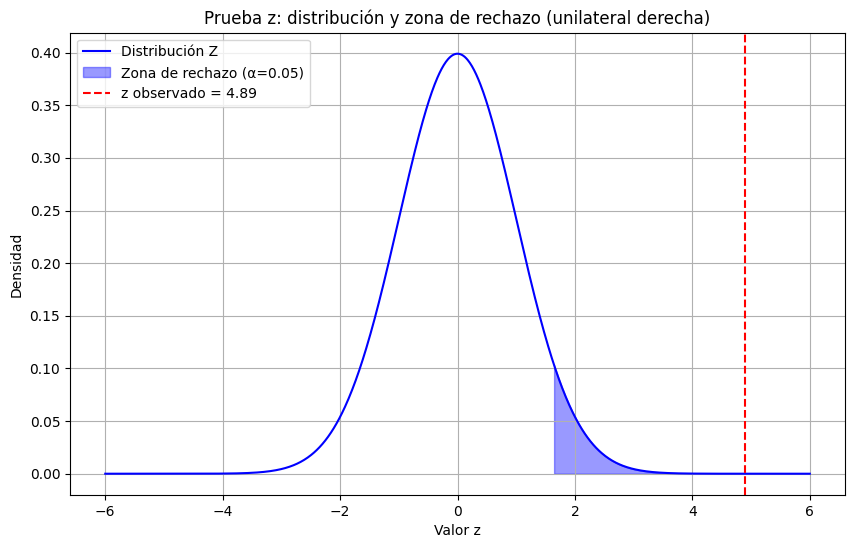

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
alpha = 0.05

# Rango de valores z y PDF
z_vals = np.linspace(-6, 6, 1000)
pdf_vals = norm.pdf(z_vals) # Distribución z

# Punto crítico para alfa unilateral derecha
z_critico = norm.ppf(1 - alpha) # Valor de z a partir del cual tendremos la zona de rechazo

# Graficar la distribución
plt.figure(figsize=(10, 6))
plt.plot(z_vals, pdf_vals, label='Distribución Z', color='blue')

# Zona de rechazo (sombreada a la derecha)
z_rechazo = np.linspace(z_critico, 6, 100) # Irá desde z_critico hasta 6, 100 datos
plt.fill_between(z_rechazo, norm.pdf(z_rechazo), color='blue', alpha=0.4, label='Zona de rechazo (α=0.05)')

# Graficar el z obtenido (línea roja vertical)
plt.axvline(z, color='red', linestyle='--', label=f'z observado = {z:.2f}')

# Etiquetas
plt.title('Prueba z: distribución y zona de rechazo (unilateral derecha)')
plt.xlabel('Valor z')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)


Con esta prueba gráfica vemos que z está en la zona de rechazo, así que nos inclinaríamos por la hipótesis alterna.

Lo anterior es opcional y lo más fácil siempre es calcular el valor p para esta prueba:

In [7]:
# Calcular p = 1 - (P(Z<=z))
p = 1 - norm.cdf(z) # Para unilateral izquierda el cálculo sería norm.cdf(z) (porque sería simplemente P(Z<=z))

print(f'z: {z}')
print(f'p: {p}')

z: 4.892782930920776
p: 4.971002073306252e-07


### 2.7. Paso 7: aceptar o rechazar $H_0$

Y vemos que $p = 4.97x10^{-7} < 0.05$ y por tanto rechazamos la hipótesis nula (medias iguales) y nos inclinamos por $H_1$ (medias diferentes).

Y por tanto:

> El modelo de segmentación 1 genera un incremento de las tasas de conversión que es estadísticamente significativo comparado con el modelo de segmentación 2 (7.4% vs. 6.9%)

### 2.8. Paso 8: evaluar el tamaño del efecto actualizado

Hemos visto que hay un efecto pero ¿qué tan grande es?

Simplemente recalculamos el tamaño del efecto con la media de los datos obtenidos. Para ello podemos usar la librería "pingouin":

In [8]:
from pingouin import compute_effsize

d = compute_effsize(df['segm1'], df['segm2'], eftype='cohen') # Cohen: la ecuación para el tamaño del efecto en pruebas z
print(f"Tamaño del efecto (d) actualizado: {d}")

Tamaño del efecto (d) actualizado: 0.7078306725572803


Según la escala de Cohen:

- 0.2 es un efecto pequeño
- 0.5 es un efecto mediano
- 0.8 es un efecto grande

Así que para este valor de 0.707 tendremos un tamaño del efecto moderadamente fuerte.

Veamos qué pasa ahora con la potencia de la prueba:

In [9]:
# Definir parámetros de la prueba actualizada (con el nuevo n)
n = len(df)
alpha = 0.05 # Nivel de significancia

# Instancia de NormalIndPower
analisis = NormalIndPower()

# Potencia actualizada
potencia = analisis.power(
    effect_size=d, # El valor calculado en el bloque de código anterior
    nobs1 = n, # tamaño de la muestra usada
    alpha = alpha,
    ratio = 1, # porque es prueba de 2 muestras y tenemos la misma cantidad de datos en cada muestra
    alternative = 'larger' # porque es unilateral derecha
)
print(f'Potencia actualizada de la prueba: {potencia}')

Potencia actualizada de la prueba: 0.9996106613624105


Lo anterior quiere decir que:

> Si realmente existe una diferencia entre las dos muestras (es decir, si $H_1$ es verdadera), entonces la prueba tiene un 99% de probabilidad de detectarla correctamente (es decir, de rechazar $H_0$).✅✅✅

Así, combinando el tamaño del efecto (mediano) con la potencia de la prueba (probabilidad alta) podemos decir que tenemos un alto nivel de confianza de que el modelo de segmentación 1 realmente es mejor que el modelo de segmentación 2.